In [1]:
%pip install ucimlrepo


Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [1]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd

In [3]:
import tarfile

In [4]:
filename = "TCGA-PANCAN-HiSeq-801x20531.tar.gz"

In [5]:
with tarfile.open(filename, "r:gz") as tar:
    tar.extractall(path="./cancer_data")
    print("Extraction complete! Files are in the 'cancer_data' folder.")


/tmp/ipykernel_572/2635859252.py:2: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path="./cancer_data")


Extraction complete! Files are in the 'cancer_data' folder.


In [8]:
X = pd.read_csv('cancer_data/TCGA-PANCAN-HiSeq-801x20531/data.csv', index_col=0)
y = pd.read_csv('cancer_data/TCGA-PANCAN-HiSeq-801x20531/labels.csv', index_col=0)

In [9]:
print(f"Data Loaded: {X.shape[0]} patients and {X.shape[1]} genes.")

Data Loaded: 801 patients and 20531 genes.


In [10]:
print(y['Class'].value_counts())

Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64


In [11]:
from sklearn.preprocessing import StandardScaler

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
from sklearn.decomposition import PCA

In [14]:
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)

In [15]:
print(f"Original shape: {X_scaled.shape}")
print(f"Reduced shape: {X_pca.shape}")

Original shape: (801, 20531)
Reduced shape: (801, 50)


In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

In [18]:
from sklearn.ensemble import RandomForestClassifier


In [19]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train.values.ravel())

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
y_pred = clf.predict(X_test)

In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        BRCA       0.97      1.00      0.98        61
        COAD       1.00      1.00      1.00        17
        KIRC       1.00      0.96      0.98        25
        LUAD       1.00      1.00      1.00        29
        PRAD       1.00      0.97      0.98        29

    accuracy                           0.99       161
   macro avg       0.99      0.99      0.99       161
weighted avg       0.99      0.99      0.99       161



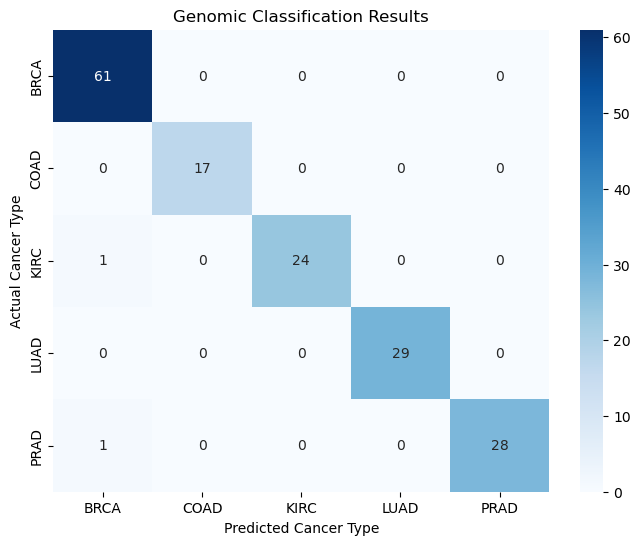

In [23]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', 
            xticklabels=clf.classes_, yticklabels=clf.classes_, cmap='Blues')
plt.xlabel('Predicted Cancer Type')
plt.ylabel('Actual Cancer Type')
plt.title('Genomic Classification Results')
plt.show()

In [24]:
from sklearn.model_selection import cross_val_score

In [25]:
scores = cross_val_score(clf, X_pca, y.values.ravel(), cv=5)

print(f"Accuracy scores for each fold: {scores}")
print(f"Average Accuracy: {scores.mean():.2%}")
print(f"Standard Deviation: {scores.std():.4f}")

Accuracy scores for each fold: [0.9689441 0.99375   0.98125   0.9875    0.9875   ]
Average Accuracy: 98.38%
Standard Deviation: 0.0084


In [26]:
import numpy as np

In [27]:
pc1_loadings = pd.Series(pca.components_[0], index=X.columns)


In [28]:
top_genes = pc1_loadings.abs().sort_values(ascending=False).head(10)


In [29]:
print("Top 10 Biomarker Genes identified by PCA:")
print(top_genes)

Top 10 Biomarker Genes identified by PCA:
gene_19862    0.019002
gene_17360    0.018985
gene_13489    0.018966
gene_15158    0.018777
gene_7031     0.018740
gene_7019     0.018657
gene_10788    0.018629
gene_13507    0.018624
gene_6543     0.018595
gene_2288     0.018592
dtype: float64


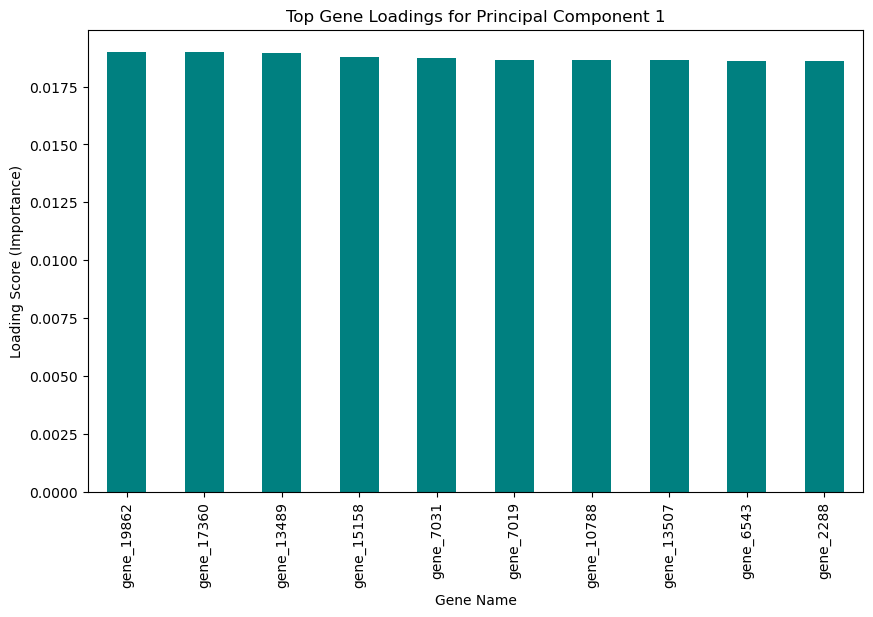

In [30]:
plt.figure(figsize=(10,6))
top_genes.plot(kind='bar', color='teal')
plt.title('Top Gene Loadings for Principal Component 1')
plt.ylabel('Loading Score (Importance)')
plt.xlabel('Gene Name')
plt.show()